# IRIS FLOWER CLASSIFICATION
### The Iris flower dataset consists of three species: setosa, versicolor, and virginica. These species can be distinguished based on their measurements. Now, imagine that you have the measurements of Iris flowers categorized by their respective species. Your objective is to train a machine learning model that can learn from these measurements and accurately classify the Iris flowers into their respective species.

## Data Loading and Pair Plot Visualization

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Iris dataset using seaborn
iris_df = sns.load_dataset('iris')

# Display the first few rows of the DataFrame
display(iris_df.head())

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [11]:
print('Summary Statistics for iris_df:')
display(iris_df.describe())

Summary Statistics for iris_df:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [12]:
print('Unique species and their counts:')
display(iris_df['species'].value_counts())

Unique species and their counts:


,count
species,
setosa,50
versicolor,50
virginica,50


In [10]:
# Check for missing values in the DataFrame
missing_values = iris_df.isnull().sum()
display(pd.DataFrame({'Missing Values': missing_values}))

,Missing Values
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


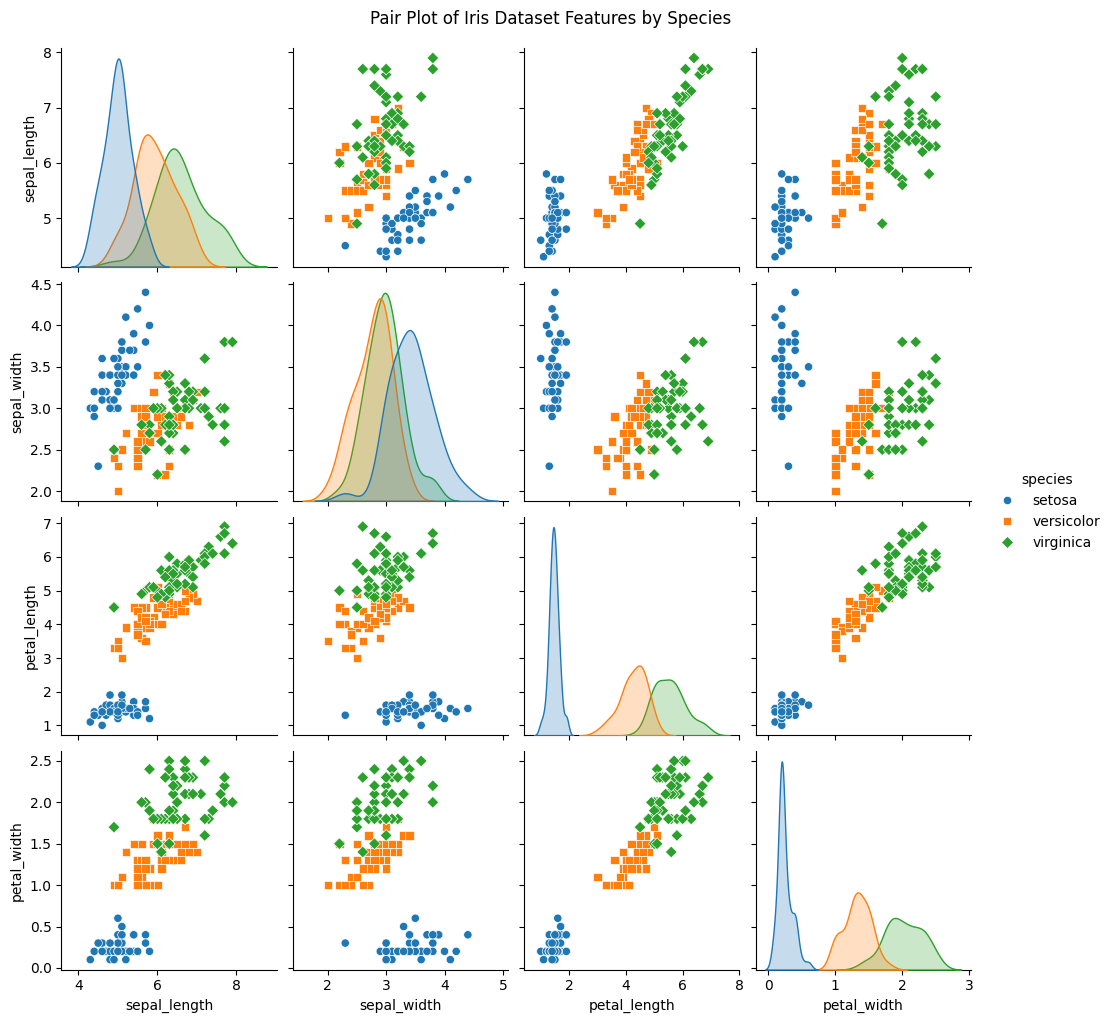

In [4]:
# Create a pair plot to visualize feature relationships
sns.pairplot(iris_df, hue='species', markers=['o', 's', 'D'])
plt.suptitle('Pair Plot of Iris Dataset Features by Species', y=1.02) # Adjust suptitle position
plt.show()

## Model Training: Random Forest Classifier

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Separate features (X) and target (y)
X = iris_df.drop('species', axis=1)
y = iris_df['species']

# Encode the target variable 'species' into numerical labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Original species labels:", y.unique())
print("Encoded species labels:", y_encoded)
print("Mapping:", list(le.classes_))


Original species labels: ['setosa' 'versicolor' 'virginica']
Encoded species labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
Mapping: ['setosa', 'versicolor', 'virginica']


In [6]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 105 samples
Test set size: 45 samples


In [7]:
# Initialize and train the Random Forest Classifier
# Using a random_state for reproducibility
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


### Model Evaluation

In [8]:
# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=le.classes_)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)
print("\nConfusion Matrix:\n", conf_matrix)


Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


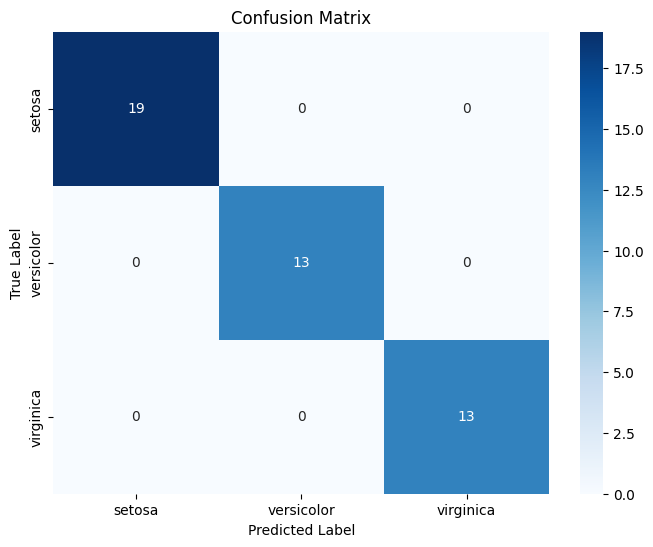

In [9]:
# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [15]:
print('Classification Report:\n', report)

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



## Feature Distribution by Species (Boxplots)

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 6.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 18.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 16.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


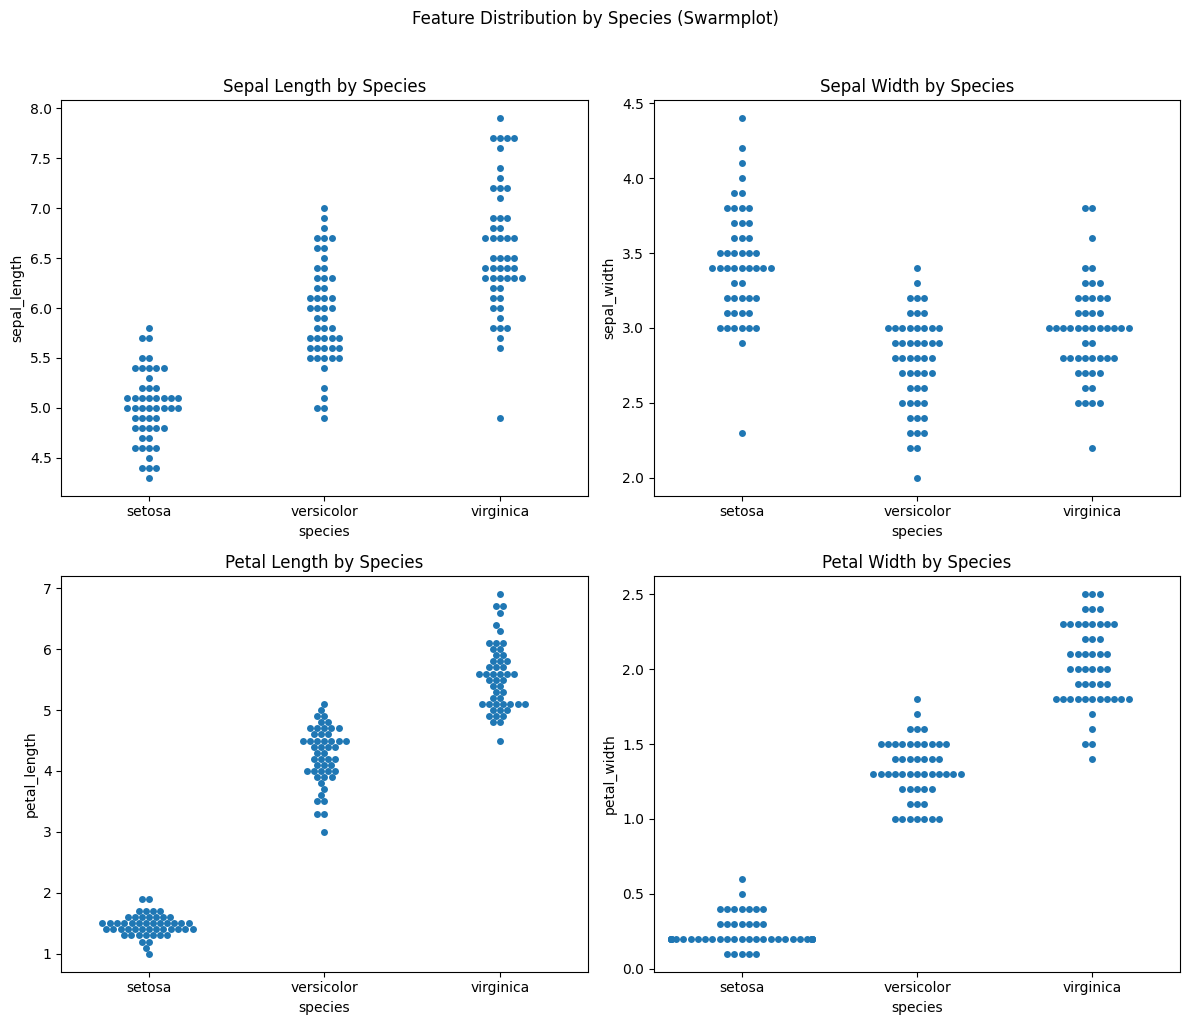

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Feature Distribution by Species', y=1.02)

sns.boxplot(ax=axes[0, 0], x='species', y='sepal_length', data=iris_df)
axes[0, 0].set_title('Sepal Length by Species')

sns.boxplot(ax=axes[0, 1], x='species', y='sepal_width', data=iris_df)
axes[0, 1].set_title('Sepal Width by Species')

sns.boxplot(ax=axes[1, 0], x='species', y='petal_length', data=iris_df)
axes[1, 0].set_title('Petal Length by Species')

sns.boxplot(ax=axes[1, 1], x='species', y='petal_width', data=iris_df)
axes[1, 1].set_title('Petal Width by Species')

plt.tight_layout()
plt.show()

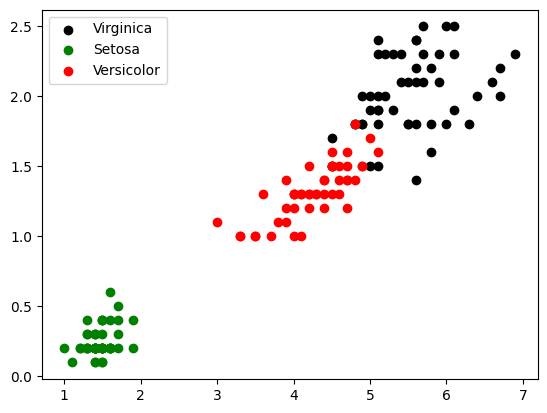

In [18]:
setosa = iris_df[iris_df['species'] == 'setosa']
versicolor = iris_df[iris_df['species'] == 'versicolor']
virginica = iris_df[iris_df['species'] == 'virginica']

plt.scatter(virginica['petal_length'],virginica['petal_width'],color='k',label='Virginica')
plt.scatter(setosa['petal_length'],setosa['petal_width'],color='g',label='Setosa')
plt.scatter(versicolor['petal_length'],versicolor['petal_width'],color='r',label='Versicolor')
plt.legend()

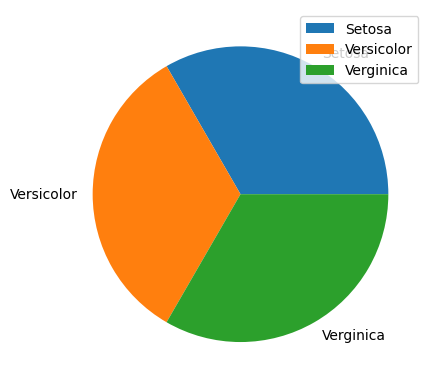

In [20]:
plt.pie(iris_df['species'].value_counts(),labels=['Setosa','Versicolor','Verginica'])
plt.legend()

### Interactive Visualization with Plotly Express

In [22]:
import plotly_express as px

# Create an interactive scatter plot using Plotly Express
fig = px.scatter(iris_df, x="petal_length", y="petal_width", color="species",
                 title="Interactive Petal Length vs. Petal Width by Species",
                 labels={"petal_length": "Petal Length (cm)", "petal_width": "Petal Width (cm)"})

fig.show()

In [24]:
import plotly_express as px

# Create an interactive 3D scatter plot with all four features
# Using 'petal_length', 'petal_width', 'sepal_length' for axes and 'sepal_width' for size
fig_3d_all_features = px.scatter_3d(iris_df, x='petal_length', y='petal_width', z='sepal_length',
                                     color='species', size='sepal_width',
                                     title='Interactive 3D Scatter Plot of All Iris Features by Species',
                                     labels={'petal_length': 'Petal Length (cm)', 'petal_width': 'Petal Width (cm)',
                                             'sepal_length': 'Sepal Length (cm)', 'sepal_width': 'Sepal Width (cm)'})

fig_3d_all_features.show()